# Project 1 — Notebook 04: Executive Dashboard
### NCR Performance Landscape — Visual Output

Generates the comprehensive 3×3 dashboard saved to
`reports/figures/project1_ncr/comprehensive_analysis.png`
and embedded in Notebook 05.

## 1. Setup

In [1]:
# Path setup
# Notebooks are in the project root alongside the .py src files.
# If your notebooks are nested (e.g. notebooks/project1/), adjust
# the os.chdir() call to match your actual depth:
#   One level deep  → os.chdir('..')
#   Two levels deep → os.chdir(os.path.join('..', '..'))
#   Same level      → no chdir needed (comment it out)
import sys, os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
%matplotlib inline

# ── Uncomment ONE of the following to match your folder depth ─────────────────
os.chdir(os.path.join('..', '..'))   # notebooks two levels deep
# os.chdir('..')                        # notebooks one level deep
# (no chdir needed if notebooks are in project root)

project_root = os.path.abspath(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"cleaned CSV  : {os.path.exists('output/cleaned_fault_ticket.csv')}")

from config import ZONE_ORDER, ZONE_PALETTE
from src.fault_ticket.metrics import calculate_zone_summary
from src.visualization import (
    plot_ticket_volume_distribution,
    plot_ticket_volume,
    plot_fault_density,
    plot_average_resolution_time,
    plot_sla_compliance,
    plot_noc_vs_field_time,   # replaces plot_average_dispatch_delay
)

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
summary = calculate_zone_summary(df)

summary_sorted = summary.set_index('ZONE').reindex(ZONE_ORDER).reset_index()
z4 = summary[summary['ZONE']=='ZONE 4'].iloc[0]
z5 = summary[summary['ZONE']=='ZONE 5'].iloc[0]

print(f"\n✅ {summary['Ticket_Count'].sum():,} tickets · {len(summary)} zones")
print(f"   Avg_NOC_Time   available: {'Avg_NOC_Time'   in summary.columns}")
print(f"   Avg_Field_Time available: {'Avg_Field_Time' in summary.columns}")

cleaned CSV  : True

✅ 36,907 tickets · 6 zones
   Avg_NOC_Time   available: True
   Avg_Field_Time available: True


## 2. Generate NCR Performance Dashboard

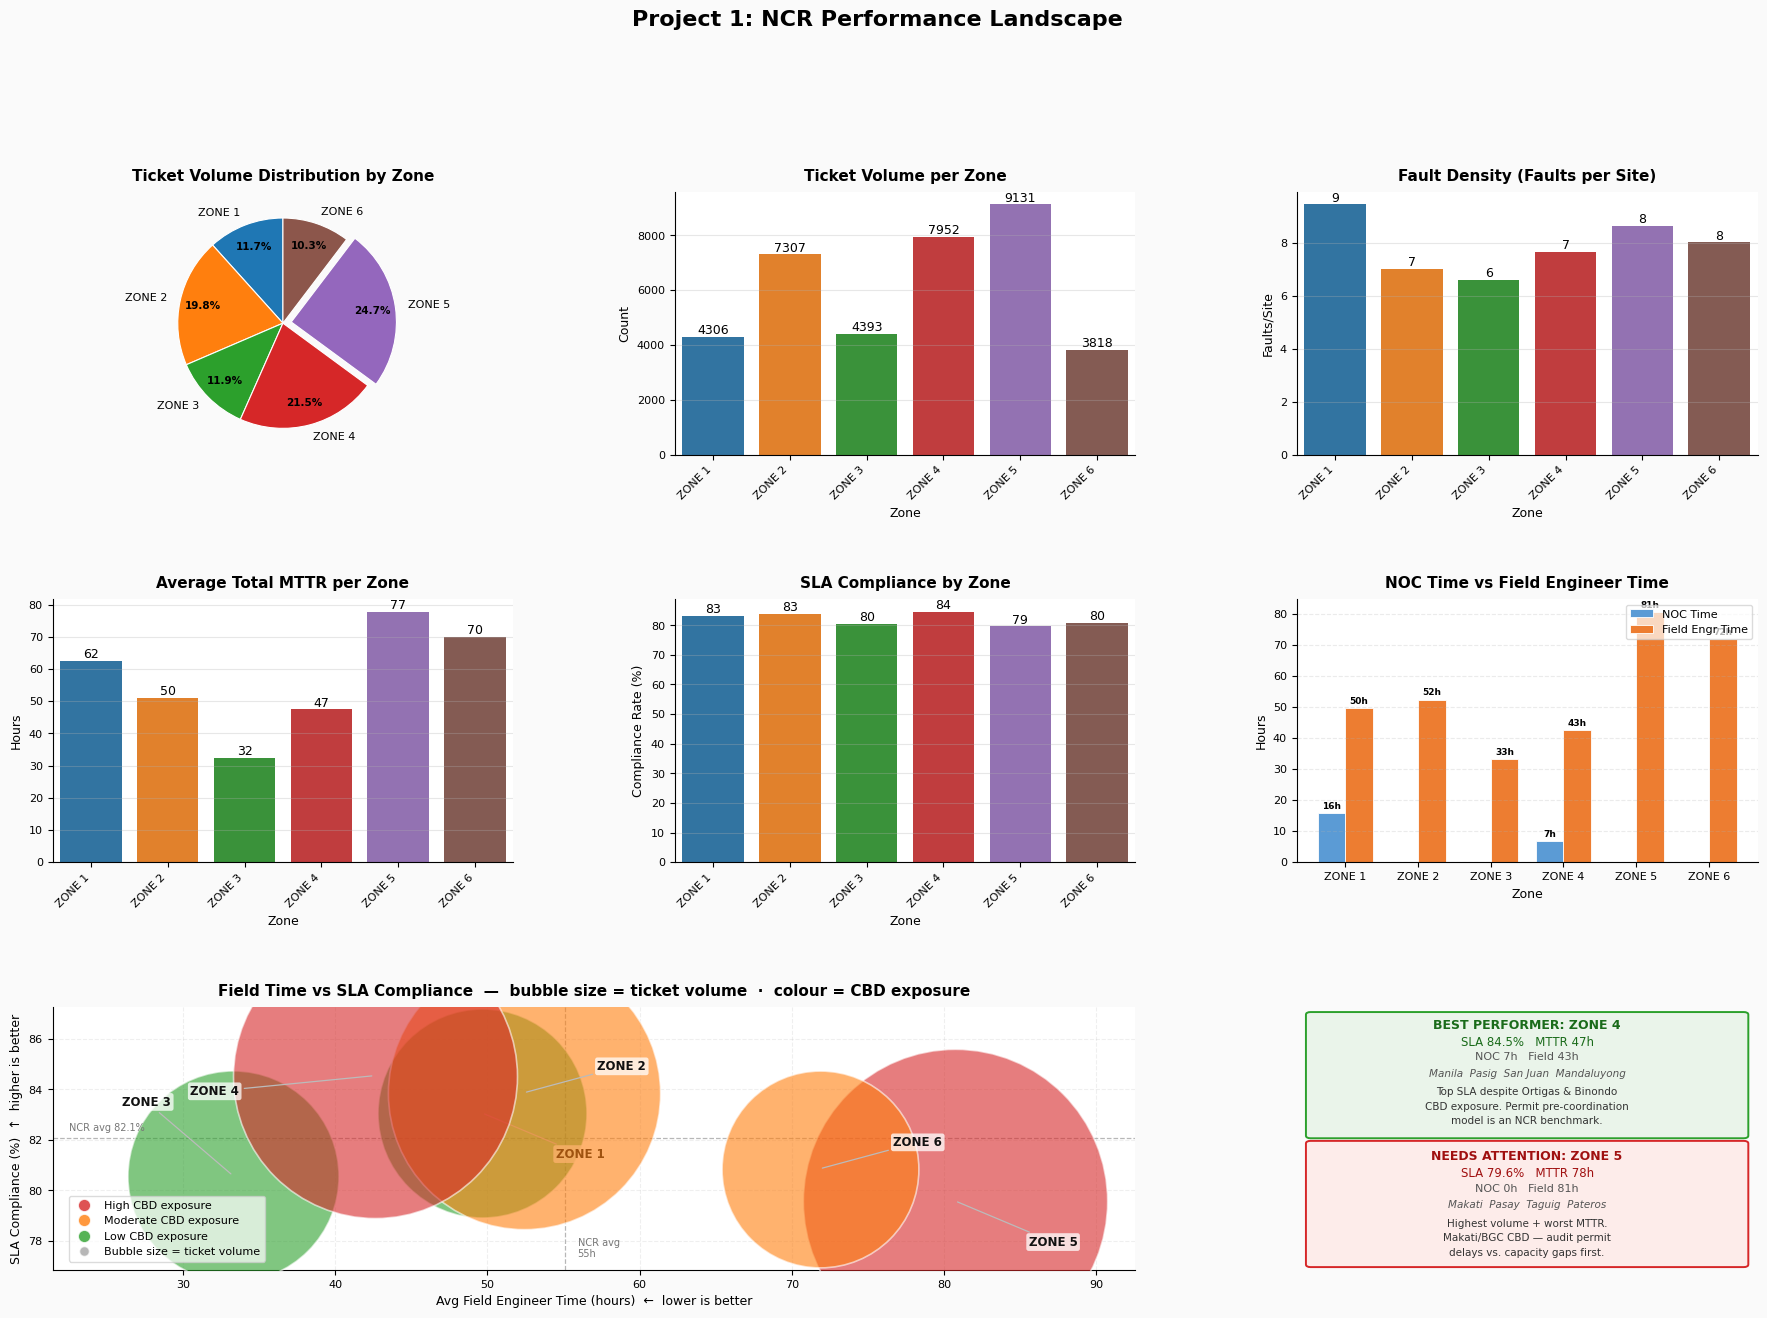

✅ Saved


In [2]:
TS=11; LS=9; VS=8; TK=8

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#fafafa')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── ROW 1: Volume ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
plot_ticket_volume_distribution(ax1, df)

ax2 = fig.add_subplot(gs[0, 1])
plot_ticket_volume(ax2, summary=summary_sorted)

ax3 = fig.add_subplot(gs[0, 2])
plot_fault_density(ax3, summary=summary_sorted)

# ── ROW 2: Performance ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
plot_average_resolution_time(ax4, summary=summary_sorted)

ax5 = fig.add_subplot(gs[1, 1])
plot_sla_compliance(ax5, summary=summary_sorted)

ax6 = fig.add_subplot(gs[1, 2])
plot_noc_vs_field_time(ax6, summary=summary_sorted)

# ── Apply consistent axis styling across all six panels ────────────────────
for ax in [ax2, ax3, ax4, ax5, ax6]:
    ax.tick_params(axis='both', labelsize=TK)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.title.set_fontsize(TS)
    ax.xaxis.label.set_fontsize(LS)
    ax.yaxis.label.set_fontsize(LS)

# ── ROW 3: Scatter — Field Time vs SLA ─────────────────────────────────────────────
# [2,:2] Bubble: x = Field Time, y = SLA, size = ticket volume, colour = CBD exposure.
# This framing makes Zone 4's benchmark status legible: it achieves top SLA under
# HIGH CBD pressure. Zone 3's strong metrics reflect a structural low-CBD advantage.
ax7 = fig.add_subplot(gs[2, :2])

# CBD exposure per zone — from operational geography
CBD_EXPOSURE = {
    'ZONE 1': ('Low',      '#2ca02c'),   # Caloocan, Navotas, Valenzuela
    'ZONE 2': ('Moderate', '#ff7f0e'),   # Quezon City
    'ZONE 3': ('Low',      '#2ca02c'),   # Rizal, Marikina, Malabon
    'ZONE 4': ('High',     '#d62728'),   # Manila, Pasig, San Juan, Mandaluyong
    'ZONE 5': ('High',     '#d62728'),   # Makati, Pasay, Taguig, Pateros
    'ZONE 6': ('Moderate', '#ff7f0e'),   # Paranaque, Las Pinas, Muntinlupa
}

size_scale = 6000 / summary_sorted['Ticket_Count'].max()

# Fix axis limits first so offsets are meaningful
# Dynamic axis limits — computed from actual data so they survive SLA threshold changes
_field_vals = summary_sorted['Avg_Field_Time']
_sla_vals   = summary_sorted['SLA_Compliance_Rate']
_x_pad = (_field_vals.max() - _field_vals.min()) * 0.25
_y_pad = (_sla_vals.max()   - _sla_vals.min())   * 0.55
ax7.set_xlim(_field_vals.min() - _x_pad,  _field_vals.max() + _x_pad)
ax7.set_ylim(_sla_vals.min()   - _y_pad,  _sla_vals.max()   + _y_pad)

# Label offsets — placed outside bubbles with leader lines
# Offsets as fractions of axis range — survive rescaling after SLA threshold changes
_xr = _field_vals.max() - _field_vals.min() + 1
_yr = _sla_vals.max()   - _sla_vals.min()   + 0.1
LABEL_OFFSETS = {
    'ZONE 1': ( _xr*0.10,  -_yr*0.35),   # right, below
    'ZONE 2': ( _xr*0.10,   _yr*0.18),   # right, above
    'ZONE 3': (-_xr*0.15,   _yr*0.55),   # left, above
    'ZONE 4': (-_xr*0.25,  -_yr*0.15),   # left, below  (separate from Z3)
    'ZONE 5': ( _xr*0.10,  -_yr*0.35),   # right, below
    'ZONE 6': ( _xr*0.10,   _yr*0.18),   # right, above
}

for _, row in summary_sorted.iterrows():
    zone = row['ZONE']
    _, color = CBD_EXPOSURE[zone]
    size = row['Ticket_Count'] * size_scale * 8
    ax7.scatter(row['Avg_Field_Time'], row['SLA_Compliance_Rate'],
                s=size, color=color, alpha=0.60, edgecolors='white', linewidth=1.2, zorder=3)
    dx, dy = LABEL_OFFSETS.get(zone, (4, 0.5))
    ax7.annotate(zone,
                 xy=(row['Avg_Field_Time'], row['SLA_Compliance_Rate']),
                 xytext=(row['Avg_Field_Time'] + dx, row['SLA_Compliance_Rate'] + dy),
                 fontsize=8.5, fontweight='bold', color='#111',
                 arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.9),
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))

# NCR average reference lines
avg_field = summary_sorted['Avg_Field_Time'].mean()
avg_sla   = summary_sorted['SLA_Compliance_Rate'].mean()
ax7.axvline(avg_field, color='#999', linestyle='--', linewidth=0.9, alpha=0.7)
ax7.axhline(avg_sla,   color='#999', linestyle='--', linewidth=0.9, alpha=0.7)
# Place reference labels inside the fixed axis range
# Reference labels — anchored to dynamic axis range
_ylo, _yhi = ax7.get_ylim()
_xlo, _xhi = ax7.get_xlim()
ax7.text(avg_field + (_xhi - _xlo)*0.012, _ylo + (_yhi - _ylo)*0.04,
         f'NCR avg\n{avg_field:.0f}h', fontsize=7, color='#777', va='bottom')
ax7.text(_xlo + (_xhi - _xlo)*0.015, avg_sla + (_yhi - _ylo)*0.02,
         f'NCR avg {avg_sla:.1f}%', fontsize=7, color='#777', va='bottom')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=9, alpha=0.8, label='High CBD exposure'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff7f0e',
           markersize=9, alpha=0.8, label='Moderate CBD exposure'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ca02c',
           markersize=9, alpha=0.8, label='Low CBD exposure'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
           markersize=7, alpha=0.6, label='Bubble size = ticket volume'),
]
ax7.legend(handles=legend_elements, fontsize=8, framealpha=0.7,
           loc='lower left', bbox_to_anchor=(0.01, 0.01))

ax7.set_title('Field Time vs SLA Compliance  —  bubble size = ticket volume  ·  colour = CBD exposure',
              fontsize=TS, fontweight='bold', pad=8)
ax7.set_xlabel('Avg Field Engineer Time (hours)  ←  lower is better', fontsize=LS)
ax7.set_ylabel('SLA Compliance (%)  ↑  higher is better', fontsize=LS)
ax7.tick_params(axis='both', labelsize=TK)
ax7.grid(alpha=0.2, linestyle='--')
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# [2,2] Key Findings — Best vs Worst
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
ax8.set_xlim(0, 1); ax8.set_ylim(0, 1)

ax8.add_patch(mpatches.FancyBboxPatch((0.03, 0.51), 0.94, 0.46,
    boxstyle='round,pad=0.01', facecolor='#eaf4ea',
    edgecolor='#2ca02c', linewidth=1.4, transform=ax8.transAxes))
ax8.add_patch(mpatches.FancyBboxPatch((0.03, 0.02), 0.94, 0.46,
    boxstyle='round,pad=0.01', facecolor='#fdecea',
    edgecolor='#d62728', linewidth=1.4, transform=ax8.transAxes))

kw = dict(transform=ax8.transAxes, ha='center', va='top')
ax8.text(0.50, 0.955, f'BEST PERFORMER: {z4["ZONE"]}',
         fontsize=9, fontweight='bold', color='#1a6b1a', **kw)
ax8.text(0.50, 0.890, f'SLA {z4["SLA_Compliance_Rate"]:.1f}%   MTTR {z4["MTTR"]:.0f}h',
         fontsize=8.5, color='#1a6b1a', **kw)
ax8.text(0.50, 0.828, f'NOC {z4["Avg_NOC_Time"]:.0f}h   Field {z4["Avg_Field_Time"]:.0f}h',
         fontsize=8, color='#555', **kw)
ax8.text(0.50, 0.765, 'Manila  Pasig  San Juan  Mandaluyong',
         fontsize=7.5, color='#555', style='italic', **kw)
ax8.text(0.50, 0.695,
         'Top SLA despite Ortigas & Binondo\nCBD exposure. Permit pre-coordination\nmodel is an NCR benchmark.',
         fontsize=7.5, color='#333', linespacing=1.55, **kw)
ax8.text(0.50, 0.455, f'NEEDS ATTENTION: {z5["ZONE"]}',
         fontsize=9, fontweight='bold', color='#a01010', **kw)
ax8.text(0.50, 0.390, f'SLA {z5["SLA_Compliance_Rate"]:.1f}%   MTTR {z5["MTTR"]:.0f}h',
         fontsize=8.5, color='#a01010', **kw)
ax8.text(0.50, 0.328, f'NOC {z5["Avg_NOC_Time"]:.0f}h   Field {z5["Avg_Field_Time"]:.0f}h',
         fontsize=8, color='#555', **kw)
ax8.text(0.50, 0.265, 'Makati  Pasay  Taguig  Pateros',
         fontsize=7.5, color='#555', style='italic', **kw)
ax8.text(0.50, 0.195,
         'Highest volume + worst MTTR.\nMakati/BGC CBD — audit permit\ndelays vs. capacity gaps first.',
         fontsize=7.5, color='#333', linespacing=1.55, **kw)

# ── Save ───────────────────────────────────────────────────────────────────
fig.suptitle('Project 1: NCR Performance Landscape',
             fontsize=16, fontweight='bold', y=1.01)

os.makedirs('reports/figures/project1_ncr', exist_ok=True)
out_path = 'reports/figures/project1_ncr/comprehensive_analysis.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved")

## 3. Notes

- **`Avg_NOC_Time`** = `DISPATCHDATE − REPORTDATE` — time NOC spent on remote troubleshooting before endorsing to field. Renamed from `Avg_Dispatch_Delay` for clarity.
- **`Avg_Field_Time`** = `RESOLVEDDATE − DISPATCHDATE` — on-site resolution time after WO issued.
- **Unknown zone tickets** are excluded from all panels via `calculate_zone_summary(exclude_unknown=True)`.
- Field time in Zones 4 and 5 is an **upper bound** — building work permit delays in CBD areas (Makati, BGC, Ortigas) are absorbed silently into field time with no distinct RFO tag.
- Dashboard image is saved and embedded in Notebook 05 for the business summary.